In [66]:
import cv2
from matplotlib import pyplot as plt
import numpy as np
from skimage.measure import label, regionprops


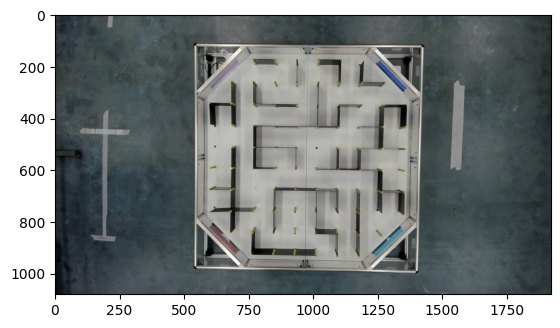

In [59]:
image = cv2.imread("maze_1.jpg")
plt.imshow(image)

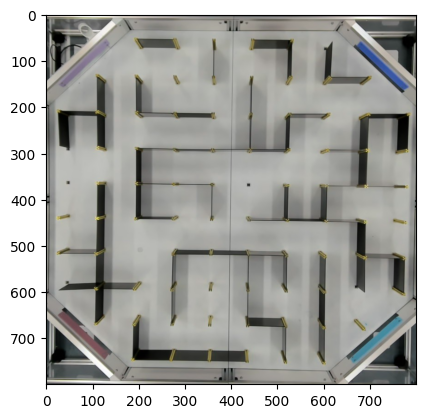

In [60]:
image = cv2.imread("maze_1.jpg")
margin = 30 


src = np.float32([
    [600 - margin, 145 - margin],     # top-left
    [1345 + margin, 145 - margin],    # top-right
    [1345 + margin, 955 + margin],    # bottom-right
    [600 - margin, 955 + margin]      # bottom-left
])

size = 800

dst = np.float32([
    [0, 0],
    [size, 0],
    [size, size],
    [0, size]
])

M = cv2.getPerspectiveTransform(src, dst)

warped = cv2.warpPerspective(
    image,
    M,
    (size, size)
)
plt.imshow(warped)


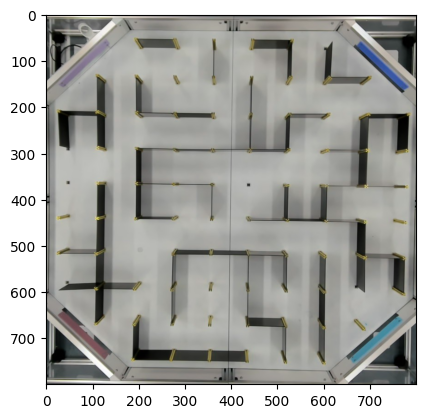

In [61]:
hsv = cv2.cvtColor(warped, cv2.COLOR_BGR2HSV)

H = hsv[:, :, 0]
S = hsv[:, :, 1]
V = hsv[:, :, 2]
plt.imshow(warped)

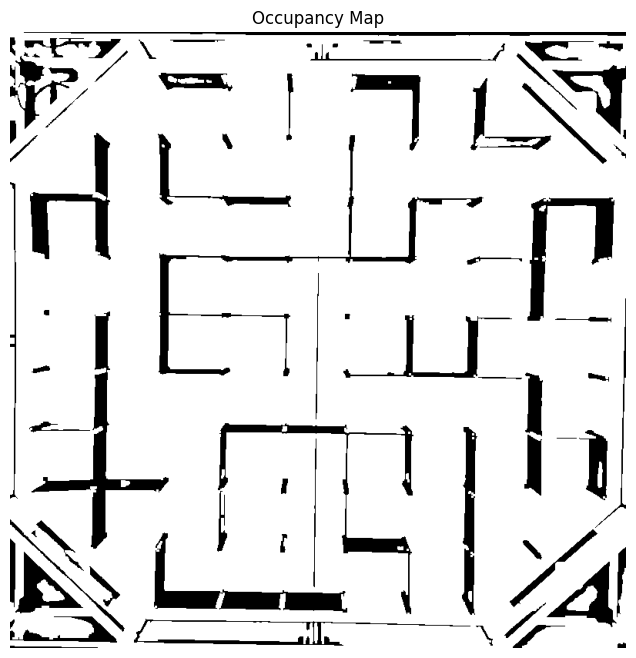

In [80]:
# diff method
gray = cv2.cvtColor(warped, cv2.COLOR_BGR2GRAY)

# Estimate the slowly-changing background illumination
background = cv2.GaussianBlur(
    gray,
    (51, 51),
    0
)

# Remove large-scale lighting/shadow variation
corrected = cv2.divide(
    gray,
    background,
    scale=255
)

wall_mask = cv2.threshold(
    corrected,
    200,
    255,
    cv2.THRESH_BINARY_INV
)[1]
# 3. Connect broken thin lines using a larger rectangular kernel_2
# Adjust kernel_2 size (e.g., 9x9 or 11x11) based on the size of missing line gaps
kernel = cv2.getStructuringElement(
    cv2.MORPH_RECT,
    (3, 3)
)

wall_mask = cv2.morphologyEx(
    wall_mask,
    cv2.MORPH_CLOSE,
    kernel,
    iterations=1
)
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
    wall_mask,
    connectivity=8
)

cleaned_walls = np.zeros_like(wall_mask)

MIN_AREA = 20

for i in range(1, num_labels):

    area = stats[i, cv2.CC_STAT_AREA]

    if area >= MIN_AREA:
        cleaned_walls[labels == i] = 255

# 5. Create final binary map (0 = wall/obstacle, 1 = traversable space for BFS)
# For BFS: 1 is free space, 0 is blocked
occupancy_map_2 = (cleaned_walls == 0).astype(np.uint8)
plt.figure(figsize=(8, 8))
plt.imshow(occupancy_map_2, cmap="gray")
plt.title("Occupancy Map")
plt.axis("off")
plt.show()

this is another approach


In [77]:
wall_mask = ((V < 105) & (S < 110)).astype(np.uint8) * 255
kernel = cv2.getStructuringElement(
    cv2.MORPH_RECT,
    (5, 5)
)

wall_mask = cv2.morphologyEx(
    wall_mask,
    cv2.MORPH_CLOSE,
    kernel
)

# wall_mask = cv2.morphologyEx(
#     wall_mask,
#     cv2.MORPH_OPEN,
#     kernel
# )


In [64]:
#dilating the walls
# robot_radius_pixels = 10

# kernel = cv2.getStructuringElement(
#     cv2.MORPH_ELLIPSE,
#     (2 * robot_radius_pixels + 1,
#      2 * robot_radius_pixels + 1)
# )

# inflated_map = cv2.dilate(
#     wall_mask,
#     kernel
# )

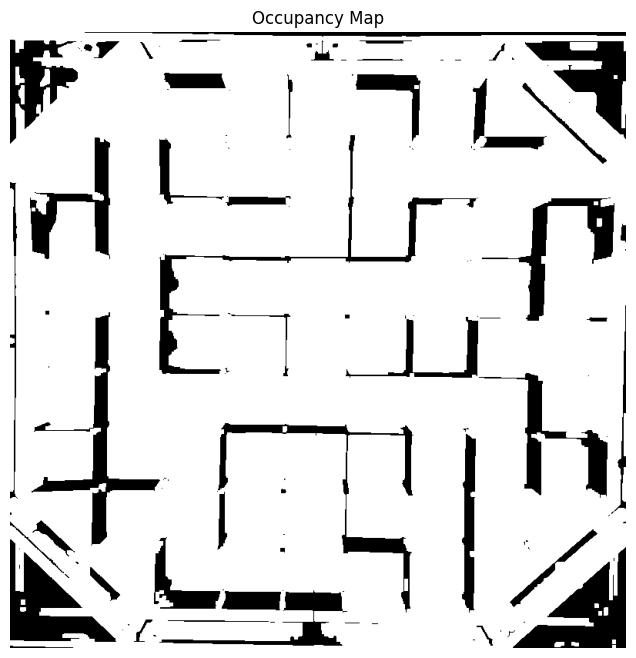

In [65]:
occupancy_map = (wall_mask > 0).astype(np.uint8)
import matplotlib.pyplot as plt
final_map = 255 - occupancy_map
plt.figure(figsize=(8, 8))
plt.imshow(final_map, cmap="gray")
plt.title("Occupancy Map")
plt.axis("off")
plt.show()

This method below connects incomplete lines or at least brings them closer


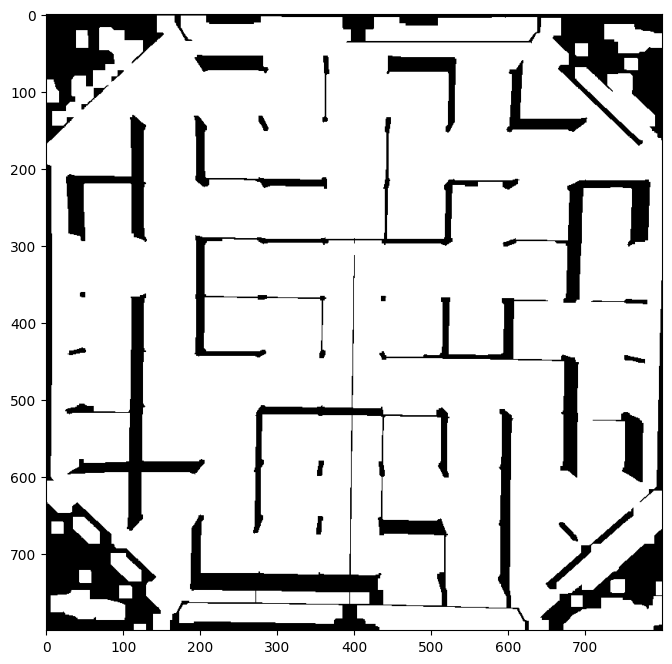

In [82]:
#trying to connect broken lines

kernel = cv2.getStructuringElement(
    cv2.MORPH_RECT,
    (15, 15)
)

connected_mask = cv2.morphologyEx(
    cleaned_walls,
    cv2.MORPH_CLOSE,
    kernel
)
labels = label(
    connected_mask,
    connectivity=1
)
clean_mask = np.zeros_like(cleaned_walls)

for region in regionprops(labels):

    if region.area >= 20:
        clean_mask[labels == region.label] = 255
final_map_2 = 255- clean_mask

plt.figure(figsize=(8, 8))
plt.imshow(final_map_2, cmap="gray")

## Starting maaking it into a graph

In [83]:
class Node:
    def __init__(self, node_id, x, y,parent = None):
        self.id = node_id
        self.x = x
        self.y = y
        self.parent = parent
    
    def get_point(self):
        return (self.x,self.y)
    
    def get_ID(self):
        return self.id

class Graph:
    def __init__(self):
        self.nodes = {}
        self.edges = {}

    def add_node(self, node_id, x, y):
        self.nodes[node_id] = Node(node_id,x,y)
        self.edges[node_id] = []

    
    def add_edge(self, node_id1, node_id2, weight=0):
        self.edges[node_id1].append((node_id2,weight))

    def remove_edge(self, node_id1, node_id2):
        for edge in self.edges[node_id1]:
            if edge[0] == node_id2:
                self.edges[node_id1].remove(edge)
            break
    
    
    def get_nodes(self):
        pass
    
    def get_edge_weight(self, node_id1, node_id2):
        for edge in self.edges[node_id1]:
            if edge[0] == node_id2:
                return edge[1]